In [38]:
%load_ext autoreload
%autoreload 2

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path
import re
from tqdm import tqdm
from scipy import sparse

from bioGraph.data_adaption import split_disease_genes
from bioGraph.ranking_methods import (
    qa_score,
    dk_score,
    rwr_score,
    diamond_score,
    neighbourhood_score,
    normalize_adjacency,
    )
from bioGraph.performance_metric import average_precision_at_k, recall_at_k
from bioGraph.utils import scores_to_ranking

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
data_dir = Path.cwd()
ppi_path = data_dir / "PPI202207.txt"
disease_path = data_dir / "pcbi.1004120.s004.txt"


Ggen = nx.Graph()
with ppi_path.open("r", encoding="utf-8") as handle:
    for raw_line in handle:
        line = raw_line.strip()
        if not line:
            continue

        parts = line.split("\t")
        if len(parts) != 4 or not parts[0].isdigit() or not parts[2].isdigit():
            continue

        entrez_a, symbol_a, entrez_b, symbol_b = parts
        entrez_a = int(entrez_a)
        entrez_b = int(entrez_b)

        Ggen.add_node(entrez_a, symbol=symbol_a)
        Ggen.add_node(entrez_b, symbol=symbol_b)
        Ggen.add_edge(entrez_a, entrez_b)


diseases = {}
current_disease = None
current_gene_chunks = []
new_record_pattern = re.compile(r"^(.*\S)\s+([/\d]+)$")
continuation_pattern = re.compile(r"^[/\d]+$")

with disease_path.open("r", encoding="utf-8") as handle:
    next(handle)
    for raw_line in handle:
        line = raw_line.strip()
        if not line:
            continue

        if continuation_pattern.fullmatch(line):
            if current_disease is not None:
                current_gene_chunks.append(line)
            continue

        match = new_record_pattern.match(line)
        if match is None:
            continue

        if current_disease is not None:
            genes = "".join(current_gene_chunks)
            diseases[current_disease] = [int(gene_id) for gene_id in genes.split("/") if gene_id]

        current_disease = match.group(1).strip()
        current_gene_chunks = [match.group(2)]

if current_disease is not None:
    genes = "".join(current_gene_chunks)
    diseases[current_disease] = [int(gene_id) for gene_id in genes.split("/") if gene_id]


print(
    f"Loaded Ggen with {Ggen.number_of_nodes():,} nodes and "
    f"{Ggen.number_of_edges():,} undirected edges."
)
print(f"Average coordination number: {2 * Ggen.number_of_edges() / Ggen.number_of_nodes():.2f}")

print(f"Loaded diseases for {len(diseases)} diseases.")
print(f"Average number of genes per disease: {np.mean([len(genes) for genes in diseases.values()]):.2f}")
print(f"Example: alzheimer disease has {len(diseases['breast neoplasms'])} genes.")


Loaded Ggen with 17,504 nodes and 354,647 undirected edges.
Average coordination number: 40.52
Loaded diseases for 70 diseases.
Average number of genes per disease: 40.61
Example: alzheimer disease has 40 genes.


In [28]:
# Example:
disease_name = "breast neoplasms"#"nutritional and metabolic diseases"#"cardiomyopathies"#"breast neoplasms"
train_genes, test_genes = split_disease_genes(disease_name, 0.5,diseases)
print(f"Train: {len(train_genes)} genes")
print(f"Test: {len(test_genes)} genes")

Train: 20 genes
Test: 20 genes


In [27]:
# Pre-compute basic matrices with explicit graph node order.
# Using range(n) would be incorrect here because Entrez node IDs are not 0..n-1.
nodelist = list(Ggen.nodes())
n = len(nodelist)

L = nx.laplacian_matrix(Ggen, nodelist=nodelist)
A_sparse = nx.adjacency_matrix(Ggen, nodelist=nodelist)
A_sparse = sparse.csr_matrix(A_sparse)
A_dense = A_sparse.toarray()
R = normalize_adjacency(Ggen, A_sparse, nodelist=nodelist)

# Hyperparameters (updated)
qa_t = 0.45
qa_diag = 5
dk_t = 0.3
rwr_return_prob = 0.4
diamond_alpha = 9
diamond_number_to_rank = 300

#running times
# RWR ~ NEI  << DK  < DIAMOND ~ QA

# Run each method directly from ranking_methods
qa_scores = qa_score(Ggen, train_genes, t=qa_t, H=A_sparse.copy(), diag=qa_diag, nodelist=nodelist)
dk_scores = dk_score(Ggen, train_genes, t=dk_t, L=L, nodelist=nodelist)
rwr_scores = rwr_score(
    Ggen,
    train_genes,
    normalized_adjacency=R,
    return_prob=rwr_return_prob,
    nodelist=nodelist,
)
diamond_scores = diamond_score(
    Ggen,
    train_genes,
    A=A_dense,
    alpha=diamond_alpha,
    number_to_rank=diamond_number_to_rank,
    nodelist=nodelist,
)
neighbourhood_scores = neighbourhood_score(
    Ggen,
    train_genes,
    A=A_sparse,
    nodelist=nodelist,
)

rankings = {
    "qa_score": scores_to_ranking(qa_scores, nodelist, Ggen, train_genes),
    "dk_score": scores_to_ranking(dk_scores, nodelist, Ggen, train_genes),
    "rwr_score": scores_to_ranking(rwr_scores, nodelist, Ggen, train_genes),
    "diamond_score": scores_to_ranking(diamond_scores, nodelist, Ggen, train_genes),
    "neighbourhood_score": scores_to_ranking(neighbourhood_scores, nodelist, Ggen, train_genes),
}

k_values = [5, 10, 20]

print(f"n={n} | Train genes: {len(train_genes)} | Test genes: {len(test_genes)}")
print("\n=== Benchmark results on current test set ===")
for method_name, ranking in rankings.items():
    print(f"\nMethod: {method_name}")
    for k in k_values:
        ap = average_precision_at_k(ranking, test_genes, k=k)
        rec = recall_at_k(ranking, test_genes, k=k)
        print(f"K={k:>3} | AP@K={ap:.4f} | Recall@K={rec:.4f}")

    ap_all = average_precision_at_k(ranking, test_genes, k=len(ranking))
    rec_all = recall_at_k(ranking, test_genes, k=len(ranking))
    print(f"K=ALL | AP@All={ap_all:.4f} | Recall@All={rec_all:.4f}")

    top5 = ranking[:5]
    top5_hits = [row for row in top5 if row["gene_id"] in set(test_genes)]
    print("Top 5 predictions:")
    for row in top5:
        print(row)
    print(f"Top-5 test hits: {len(top5_hits)}")

n=17504 | Train genes: 299 | Test genes: 300

=== Benchmark results on current test set ===

Method: qa_score
K=  5 | AP@K=0.0000 | Recall@K=0.0000
K= 10 | AP@K=0.0167 | Recall@K=0.0033
K= 20 | AP@K=0.0150 | Recall@K=0.0067
K=ALL | AP@All=0.0400 | Recall@All=0.9833
Top 5 predictions:
{'gene_id': 2315, 'symbol': 'MLANA', 'score': 0.11589810390013229}
{'gene_id': 144132, 'symbol': 'DNHD1', 'score': 0.10777737806515598}
{'gene_id': 6846, 'symbol': 'XCL2', 'score': 0.10478983794457038}
{'gene_id': 4543, 'symbol': 'MTNR1A', 'score': 0.10165431314728947}
{'gene_id': 6752, 'symbol': 'SSTR2', 'score': 0.09909810677077038}
Top-5 test hits: 0

Method: dk_score
K=  5 | AP@K=0.0400 | Recall@K=0.0033
K= 10 | AP@K=0.0200 | Recall@K=0.0033
K= 20 | AP@K=0.0100 | Recall@K=0.0033
K=ALL | AP@All=0.0307 | Recall@All=0.9833
Top 5 predictions:
{'gene_id': 2315, 'symbol': 'MLANA', 'score': 0.19909564027316465}
{'gene_id': 144132, 'symbol': 'DNHD1', 'score': 0.15069432151429815}
{'gene_id': 440387, 'symbol': 

In [41]:
# aNEI (weighted=False), rNEI (weighted=True), and RWR benchmark
# Setup: disease='breast neoplasms', N=30 runs, constant split fraction.

disease_name = "breast neoplasms"
split_fraction = 0.5
num_runs = 30
base_seed = 0
k_values_eval = [20, 100]

results_runs = []

for run_idx in range(num_runs):
    split_seed = base_seed + run_idx
    train_genes_run, test_genes_run = split_disease_genes(
        disease_name,
        split_fraction,
        diseases_dict=diseases,
        random_state=split_seed,
    )

    # aNEI: absolute number of seed-neighbour connections (weighted=False)
    anei_scores_run = neighbourhood_score(
        Ggen,
        train_genes_run,
        A=A_sparse,
        nodelist=nodelist,
        weighted=False,
    )
    anei_ranking_run = scores_to_ranking(anei_scores_run, nodelist, Ggen, train_genes_run)

    # rNEI: normalized by node degree (weighted=True)
    rnei_scores_run = neighbourhood_score(
        Ggen,
        train_genes_run,
        A=A_sparse,
        nodelist=nodelist,
        weighted=True,
    )
    rnei_ranking_run = scores_to_ranking(rnei_scores_run, nodelist, Ggen, train_genes_run)

    # RWR reference
    rwr_scores_run = rwr_score(
        Ggen,
        train_genes_run,
        normalized_adjacency=R,
        return_prob=rwr_return_prob,
        nodelist=nodelist,
    )
    rwr_ranking_run = scores_to_ranking(rwr_scores_run, nodelist, Ggen, train_genes_run)

    row = {"seed": split_seed}
    for k_eval in k_values_eval:
        row[f"aNEI_AP@{k_eval}"] = average_precision_at_k(anei_ranking_run, test_genes_run, k=k_eval)
        row[f"aNEI_Recall@{k_eval}"] = recall_at_k(anei_ranking_run, test_genes_run, k=k_eval)
        row[f"rNEI_AP@{k_eval}"] = average_precision_at_k(rnei_ranking_run, test_genes_run, k=k_eval)
        row[f"rNEI_Recall@{k_eval}"] = recall_at_k(rnei_ranking_run, test_genes_run, k=k_eval)
        row[f"RWR_AP@{k_eval}"] = average_precision_at_k(rwr_ranking_run, test_genes_run, k=k_eval)
        row[f"RWR_Recall@{k_eval}"] = recall_at_k(rwr_ranking_run, test_genes_run, k=k_eval)

    results_runs.append(row)


def _method_stats(results, method, metric, k_eval):
    vals = np.array([row[f"{method}_{metric}@{k_eval}"] for row in results], dtype=float)
    return vals.mean(), vals.std()


def print_k_table(results, k_eval):
    print(f"\nResults for K={k_eval}")
    print(
        "seed | "
        " aNEI AP  aNEI Rec | "
        " rNEI AP  rNEI Rec | "
        "  RWR AP   RWR Rec"
    )
    print("-----+-------------------+-------------------+-----------------")

    for row in results:
        print(
            f"{row['seed']:>4} | "
            f"{row[f'aNEI_AP@{k_eval}']:.4f}   {row[f'aNEI_Recall@{k_eval}']:.4f}  | "
            f"{row[f'rNEI_AP@{k_eval}']:.4f}   {row[f'rNEI_Recall@{k_eval}']:.4f}  | "
            f"{row[f'RWR_AP@{k_eval}']:.4f}   {row[f'RWR_Recall@{k_eval}']:.4f}"
        )


def print_summary_table(results, k_values):
    print("\nSummary (mean +/- std)")
    print("K   | method |       AP (mean +/- std) |   Recall (mean +/- std)")
    print("----+--------+--------------------------+------------------------")

    for k_eval in k_values:
        for method in ["aNEI", "rNEI", "RWR"]:
            ap_mean, ap_std = _method_stats(results, method, "AP", k_eval)
            rec_mean, rec_std = _method_stats(results, method, "Recall", k_eval)
            print(
                f"{k_eval:>3} | {method:<6} | "
                f"{ap_mean:>7.4f} +/- {ap_std:<7.4f} | "
                f"{rec_mean:>7.4f} +/- {rec_std:<7.4f}"
            )


# for k_eval in k_values_eval:
#     print_k_table(results_runs, k_eval)

print_summary_table(results_runs, k_values_eval)


Summary (mean +/- std)
K   | method |       AP (mean +/- std) |   Recall (mean +/- std)
----+--------+--------------------------+------------------------
 20 | aNEI   |  0.0499 +/- 0.0414  |  0.1083 +/- 0.0593 
 20 | rNEI   |  0.0020 +/- 0.0040  |  0.0150 +/- 0.0229 
 20 | RWR    |  0.0138 +/- 0.0136  |  0.0550 +/- 0.0299 
100 | aNEI   |  0.0587 +/- 0.0447  |  0.2033 +/- 0.0785 
100 | rNEI   |  0.0029 +/- 0.0041  |  0.0533 +/- 0.0364 
100 | RWR    |  0.0202 +/- 0.0142  |  0.1550 +/- 0.0538 


## Data generation

In [49]:
# Multi-disease benchmark artifact for downstream analysis
disease_set = ["breast neoplasms", "cardiomyopathies", "nutritional and metabolic diseases","adrenal gland diseases","arrhythmias cardiac","cerebrovascular disorders"]
method_set = ["aNEI", "rNEI", "RWR", "DK", "QA", "DIAMOND"]
num_runs = 30
split_fraction = 0.5
base_seed = 0

pickle_path = Path.cwd() / "results_methods_by_disease.pkl"

benchmark_results = {
    "config": {
        "disease_set": disease_set,
        "method_set": method_set,
        "num_runs": num_runs,
        "split_fraction": split_fraction,
        "base_seed": base_seed,
        "hyperparameters": {
            "rwr_return_prob": 0.4,
            "qa_t": 0.45,
            "qa_diag": 5,
            "dk_t": 0.3,
            "diamond_alpha": 9,
            "diamond_number_to_rank": 300,
        },
    },
    "runs": [],
}

for disease_name in tqdm(disease_set, desc="Processing diseases"):
    if disease_name not in diseases:
        raise ValueError(f"Disease '{disease_name}' not found in diseases.")

    for seed in range(num_runs):
        split_seed = base_seed + seed
        train_genes_run, test_genes_run = split_disease_genes(
            disease_name,
            split_fraction,
            diseases_dict=diseases,
            random_state=split_seed,
        )

        qa_scores_run = qa_score(Ggen, train_genes, t=benchmark_results["config"]["hyperparameters"]["qa_t"], H=A_sparse.copy(), diag=benchmark_results["config"]["hyperparameters"]["qa_diag"], nodelist=nodelist)
        
        dk_scores_run = dk_score(Ggen, train_genes, t=benchmark_results["config"]["hyperparameters"]["dk_t"], L=L, nodelist=nodelist)

        rnei_scores_run, anei_scores_run = neighbourhood_score(
            Ggen,
            train_genes_run,
            A=A_sparse,
            nodelist=nodelist,
            weighted='both',
        )

        rwr_scores_run = rwr_score(
            Ggen,
            train_genes_run,
            normalized_adjacency=R,
            return_prob=benchmark_results["config"]["hyperparameters"]["rwr_return_prob"],
            nodelist=nodelist,
        )

        diamond_scores_run = diamond_score(
            Ggen,
            train_genes,
            A=A_dense,
            alpha=benchmark_results["config"]["hyperparameters"]["diamond_alpha"],
            number_to_rank=benchmark_results["config"]["hyperparameters"]["diamond_number_to_rank"],
            nodelist=nodelist,
        )

        benchmark_results["runs"].append(
            {
                "disease": disease_name,
                "seed": split_seed,
                "train_genes": list(map(int, train_genes_run)),
                "test_genes": list(map(int, test_genes_run)),
                "scores": {
                    "aNEI": np.asarray(anei_scores_run, dtype=float),
                    "rNEI": np.asarray(rnei_scores_run, dtype=float),
                    "RWR": np.asarray(rwr_scores_run, dtype=float),
                    "DK": np.asarray(dk_scores_run, dtype=float),
                    "QA": np.asarray(qa_scores_run, dtype=float),
                    "DIAMOND": np.asarray(diamond_scores_run, dtype=float),
                },
            }
        )

with pickle_path.open("wb") as handle:
    pickle.dump(benchmark_results, handle, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved benchmark results to: {pickle_path}")
print(f"Total entries: {len(benchmark_results['runs'])}")
print("Example run keys:", list(benchmark_results["runs"][0].keys()) if benchmark_results["runs"] else [])

Processing diseases: 100%|██████████| 6/6 [42:27<00:00, 424.63s/it]

Saved benchmark results to: /Users/valentin/Documents/1_Promotion/Biological Networks/bioGraph/results_methods_by_disease.pkl
Total entries: 180
Example run keys: ['disease', 'seed', 'train_genes', 'test_genes', 'scores']


## Data analysis

In [51]:
# Load generated benchmark artifact and summarize AP/Recall at K=25 and K=300.
pickle_path = Path.cwd() / "results_methods_by_6disease.pkl"
with pickle_path.open("rb") as handle:
    benchmark_results_loaded = pickle.load(handle)

method_set = benchmark_results_loaded["config"]["method_set"]
disease_set = benchmark_results_loaded["config"]["disease_set"]
runs = benchmark_results_loaded["runs"]
k_values_interest = [25, 300]


def format_mean_std_to_first_sig_digit(mean_value, std_value):
    """
    Round std to one significant digit and format mean with matching precision.
    Returns a string like '0.010 +/- 0.009'.
    """
    std_value = float(std_value)
    mean_value = float(mean_value)

    if std_value == 0.0:
        # Keep a stable default precision when variability is zero.
        return f"{mean_value:.4f} +/- {0.0:.4f}"

    order = int(np.floor(np.log10(abs(std_value))))
    decimals = max(0, -order)

    std_rounded = round(std_value, decimals)
    mean_rounded = round(mean_value, decimals)

    mean_str = f"{mean_rounded:.{decimals}f}"
    std_str = f"{std_rounded:.{decimals}f}"
    return f"{mean_str} +/- {std_str}"


def summarize_metric_table(metric_name, k_eval):
    """Return table[ disease ][ method ] = formatted mean +/- std string."""
    table = {disease_name: {} for disease_name in disease_set}

    for disease_name in disease_set:
        disease_runs = [row for row in runs if row["disease"] == disease_name]

        for method_name in method_set:
            metric_values = []

            for row in disease_runs:
                scores = np.asarray(row["scores"][method_name], dtype=float)
                ranking = scores_to_ranking(scores, nodelist, Ggen, row["train_genes"])

                if metric_name == "AP":
                    metric_value = average_precision_at_k(ranking, row["test_genes"], k=k_eval)
                elif metric_name == "Recall":
                    metric_value = recall_at_k(ranking, row["test_genes"], k=k_eval)
                else:
                    raise ValueError(f"Unknown metric_name: {metric_name}")

                metric_values.append(metric_value)

            values_arr = np.asarray(metric_values, dtype=float)
            mean_value = values_arr.mean()
            std_value = values_arr.std(ddof=0)
            table[disease_name][method_name] = format_mean_std_to_first_sig_digit(mean_value, std_value)

    return table


def render_table(title, table, methods):
    """Return a pretty disease x method table as a string."""
    lines = []
    lines.append("")
    lines.append(title)
    disease_col_width = max(len("Disease"), max(len(d) for d in table))
    method_col_width = {m: max(len(m), 16) for m in methods}

    header = "Disease".ljust(disease_col_width) + " | " + " | ".join(
        m.ljust(method_col_width[m]) for m in methods
    )
    sep = "-" * len(header)
    lines.append(header)
    lines.append(sep)

    for disease_name in table:
        row_values = [table[disease_name][m].ljust(method_col_width[m]) for m in methods]
        lines.append(disease_name.ljust(disease_col_width) + " | " + " | ".join(row_values))

    return "\n".join(lines)


table_ap_25 = summarize_metric_table("AP", 25)
table_ap_300 = summarize_metric_table("AP", 300)
table_recall_25 = summarize_metric_table("Recall", 25)
table_recall_300 = summarize_metric_table("Recall", 300)

text_blocks = [
    render_table("AP@25 (mean +/- std)", table_ap_25, method_set),
    render_table("AP@300 (mean +/- std)", table_ap_300, method_set),
    render_table("Recall@25 (mean +/- std)", table_recall_25, method_set),
    render_table("Recall@300 (mean +/- std)", table_recall_300, method_set),
]
full_report = "\n\n".join(text_blocks)

print(full_report)

report_path = Path.cwd() / "results_methods_summary_tables.txt"
report_path.write_text(full_report + "\n", encoding="utf-8")
print(f"\nSaved summary tables to: {report_path}")

analysis_results = {
    "AP@25": table_ap_25,
    "AP@300": table_ap_300,
    "Recall@25": table_recall_25,
    "Recall@300": table_recall_300,
    "report_path": str(report_path),
}


AP@25 (mean +/- std)
Disease                            | aNEI             | rNEI             | RWR              | DK               | QA               | DIAMOND         
----------------------------------------------------------------------------------------------------------------------------------------------------
breast neoplasms                   | 0.05 +/- 0.04    | 0.002 +/- 0.004  | 0.02 +/- 0.01    | 0.14 +/- 0.06    | 0.37 +/- 0.07    | 0.03 +/- 0.03   
cardiomyopathies                   | 0.009 +/- 0.008  | 0.002 +/- 0.004  | 0.010 +/- 0.009  | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000
nutritional and metabolic diseases | 0.009 +/- 0.008  | 0.006 +/- 0.007  | 0.05 +/- 0.03    | 0.02 +/- 0.02    | 0.02 +/- 0.02    | 0.03 +/- 0.02   
adrenal gland diseases             | 0.002 +/- 0.005  | 0.001 +/- 0.003  | 0.004 +/- 0.004  | 0.0000 +/- 0.0000 | 0.002 +/- 0.002  | 0.0000 +/- 0.0000
arrhythmias cardiac                | 0.0000 +/- 0.0000 | 0.01 +/- 0.03    | 0.0

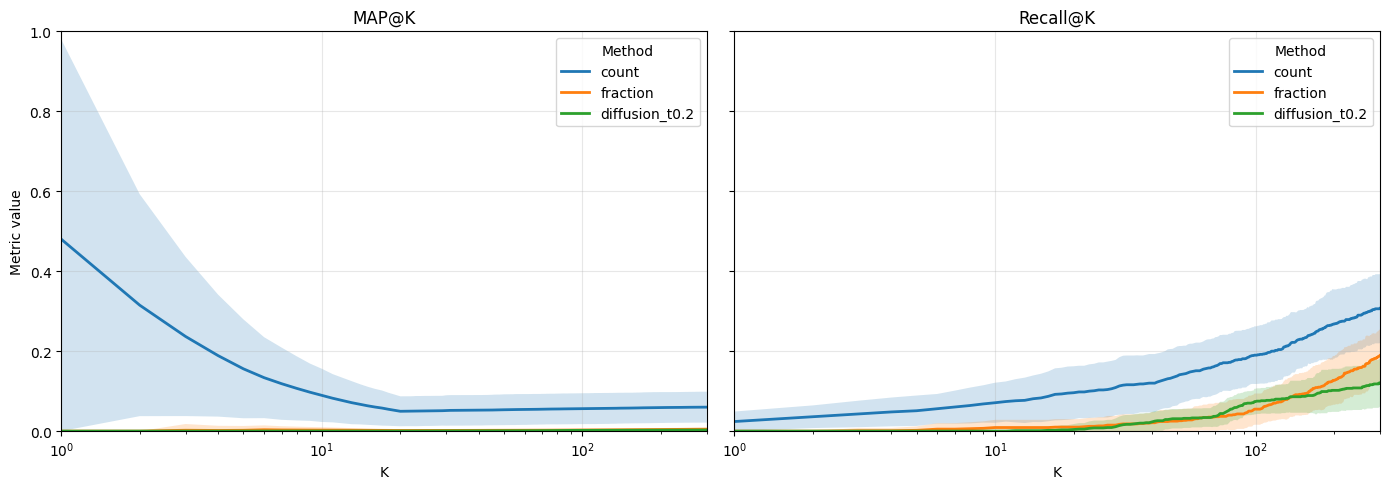

In [65]:
# Plot MAP@K and Recall@K with +/- 1 std tubes for all methods in results
k_vals = results["k_values"]
by_method = results["by_method"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
ax_ap, ax_recall = axes

for method_name, values in by_method.items():
    map_mean = values["ap_mean"]
    map_std = values["ap_std"]
    recall_mean = values["recall_mean"]
    recall_std = values["recall_std"]

    ax_ap.plot(k_vals, map_mean, linewidth=2, label=f"{method_name}")
    ax_ap.fill_between(
        k_vals,
        np.clip(map_mean - map_std, 0.0, 1.0),
        np.clip(map_mean + map_std, 0.0, 1.0),
        alpha=0.2,
    )

    ax_recall.plot(k_vals, recall_mean, linewidth=2, label=f"{method_name}")
    ax_recall.fill_between(
        k_vals,
        np.clip(recall_mean - recall_std, 0.0, 1.0),
        np.clip(recall_mean + recall_std, 0.0, 1.0),
        alpha=0.2,
    )

ax_ap.set_title("MAP@K")
ax_recall.set_title("Recall@K")

for ax in axes:
    ax.set_xlabel("K")
    ax.set_xlim(1, int(k_vals[-1]))
    ax.set_xscale("log")
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", title="Method")

ax_ap.set_ylabel("Metric value")

plt.tight_layout()
plt.show()

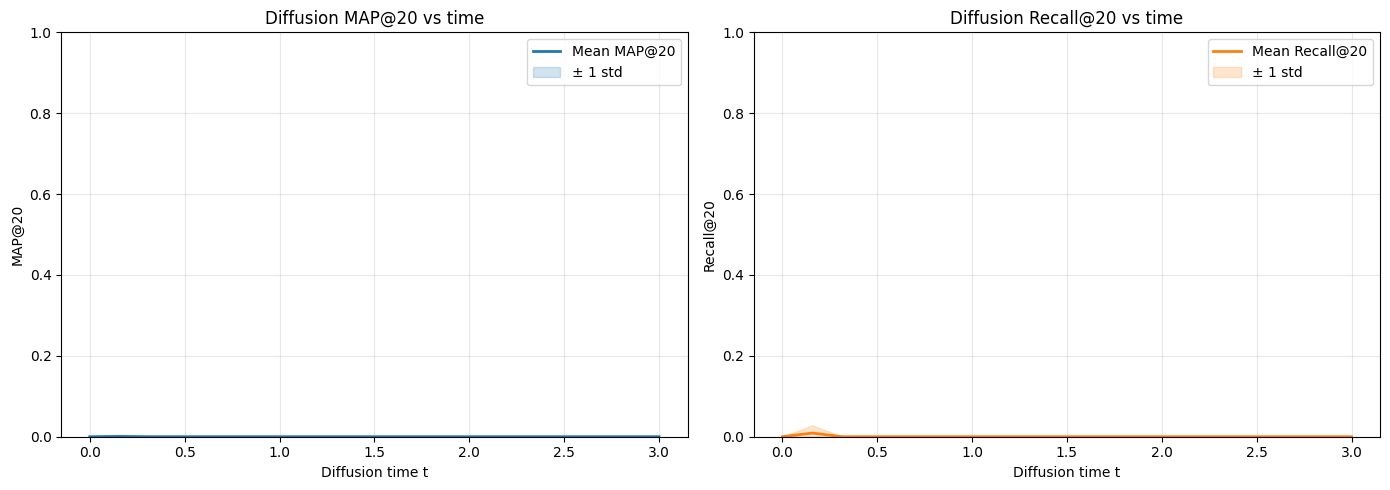

In [66]:
def evaluate_diffusion_over_time(
    disease_name,
    split_fraction,
    num_runs,
    time_values,
    k=20,
    diseases_dict=None,
    graph=None,
    random_seed=None,
):
    """
    Evaluate diffusion ranking over a grid of diffusion times.

    For each run, a new random train/test split is created. For each diffusion
    time t, the diffusion-based ranking is computed from the training genes,
    then AP@k and Recall@k are evaluated against the test genes.

    Parameters
    ----------
    disease_name : str
        Disease key in diseases_dict.
    split_fraction : float
        Fraction of genes used for training in each run.
    num_runs : int
        Number of random seeds / random splits.
    time_values : iterable of float
        Diffusion times to evaluate.
    k : int, optional
        Cutoff for AP@k and Recall@k.
    diseases_dict : dict, optional
        Disease-to-genes mapping. If None, uses global diseases.
    graph : networkx.Graph, optional
        Graph to score on. If None, uses global Ggen.
    random_seed : int, optional
        Base seed for reproducible repeated runs.

    Returns
    -------
    results : dict
        Contains time_values, ap_runs, recall_runs, ap_mean, ap_std,
        recall_mean, recall_std.
    """
    if diseases_dict is None:
        diseases_dict = diseases
    if graph is None:
        graph = Ggen

    time_values = np.asarray(list(time_values), dtype=float)
    if time_values.ndim != 1 or time_values.size == 0:
        raise ValueError("time_values must be a non-empty 1D iterable.")
    if num_runs <= 0:
        raise ValueError("num_runs must be a positive integer.")
    if k <= 0:
        raise ValueError("k must be a positive integer.")
    if disease_name not in diseases_dict:
        raise ValueError(f"Disease '{disease_name}' not found.")

    ap_runs = np.zeros((num_runs, len(time_values)), dtype=float)
    recall_runs = np.zeros((num_runs, len(time_values)), dtype=float)

    for run_idx in range(num_runs):
        run_seed = None if random_seed is None else random_seed + run_idx
        train_genes, test_genes = split_disease_genes(
            disease_name,
            split_fraction,
            diseases_dict=diseases_dict,
            random_state=run_seed,
        )

        for time_idx, t_value in enumerate(time_values):
            ranking = rank_genes_by_diffusion(
                train_genes,
                graph=graph,
                diseases_dict=diseases_dict,
                exclude_input_genes=True,
                t=float(t_value),
            )
            ap_runs[run_idx, time_idx] = average_precision_at_k(ranking, test_genes, k=k)
            recall_runs[run_idx, time_idx] = recall_at_k(ranking, test_genes, k=k)

    results = {
        "time_values": time_values,
        "k": k,
        "ap_runs": ap_runs,
        "recall_runs": recall_runs,
        "ap_mean": ap_runs.mean(axis=0),
        "ap_std": ap_runs.std(axis=0),
        "recall_mean": recall_runs.mean(axis=0),
        "recall_std": recall_runs.std(axis=0),
    }
    return results


# Example: diffusion time sweep from 0 to 3 with 20 steps
# Replace num_runs if you want more or fewer random seeds.
diffusion_time_results = evaluate_diffusion_over_time(
    disease_name="breast neoplasms",
    split_fraction=0.5,
    num_runs=50,
    time_values=np.linspace(0.0, 3.0, 20),
    k=20,
    random_seed=42,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
ax_map, ax_recall = axes

t_vals = diffusion_time_results["time_values"]
map_mean = diffusion_time_results["ap_mean"]
map_std = diffusion_time_results["ap_std"]
recall_mean = diffusion_time_results["recall_mean"]
recall_std = diffusion_time_results["recall_std"]

ax_map.plot(t_vals, map_mean, color="tab:blue", linewidth=2, label="Mean MAP@20")
ax_map.fill_between(
    t_vals,
    np.clip(map_mean - map_std, 0.0, 1.0),
    np.clip(map_mean + map_std, 0.0, 1.0),
    color="tab:blue",
    alpha=0.2,
    label="± 1 std",
)
ax_map.set_title("Diffusion MAP@20 vs time")
ax_map.set_xlabel("Diffusion time t")
ax_map.set_ylabel("MAP@20")
ax_map.set_ylim(0, 1.0)
ax_map.grid(True, alpha=0.3)
ax_map.legend(loc="best")

ax_recall.plot(t_vals, recall_mean, color="tab:orange", linewidth=2, label="Mean Recall@20")
ax_recall.fill_between(
    t_vals,
    np.clip(recall_mean - recall_std, 0.0, 1.0),
    np.clip(recall_mean + recall_std, 0.0, 1.0),
    color="tab:orange",
    alpha=0.2,
    label="± 1 std",
)
ax_recall.set_title("Diffusion Recall@20 vs time")
ax_recall.set_xlabel("Diffusion time t")
ax_recall.set_ylabel("Recall@20")
ax_recall.set_ylim(0, 1.0)
ax_recall.grid(True, alpha=0.3)
ax_recall.legend(loc="best")

plt.tight_layout()
plt.show()

In [10]:
# Duplicate benchmark block removed.
# Use Cell 4 to run qa_score, dk_score, rwr_score, diamond_score evaluation.

Train genes: 20 | Test genes: 20

=== Benchmark results on current test set ===

Method: qa_score
K=  5 | AP@K=0.0000 | Recall@K=0.0000
K= 10 | AP@K=0.0000 | Recall@K=0.0000
K= 20 | AP@K=0.0000 | Recall@K=0.0000
K=ALL | AP@All=0.0098 | Recall@All=1.0000
Top 10 predictions:
{'gene_id': 5291, 'symbol': 'PIK3CB', 'score': 0.05098617210071318}
{'gene_id': 23172, 'symbol': 'FAM175B', 'score': 0.03421157475743413}
{'gene_id': 2254, 'symbol': 'FGF9', 'score': 0.032962569961230356}
{'gene_id': 162998, 'symbol': 'OR7D2', 'score': 0.03202701699761427}
{'gene_id': 4361, 'symbol': 'MRE11', 'score': 0.031401490325586964}
{'gene_id': 79184, 'symbol': 'BRCC3', 'score': 0.029729944449197514}
{'gene_id': 253635, 'symbol': 'CCDC75', 'score': 0.029639420848351587}
{'gene_id': 7516, 'symbol': 'XRCC2', 'score': 0.029456617429565665}
{'gene_id': 9577, 'symbol': 'BRE', 'score': 0.02917138244154106}
{'gene_id': 5980, 'symbol': 'REV3L', 'score': 0.028812143071760034}
Top-10 test hits: 0

Method: dk_score
K=  5

In [31]:
import time
import numpy as np
from scipy.stats import hypergeom


# --- Local helpers for reference implementations ---
def _seed_indices_local(seed_list, nodelist):
    node_to_idx = {node: idx for idx, node in enumerate(nodelist)}
    return np.asarray([node_to_idx[node] for node in seed_list if node in node_to_idx], dtype=int)


def _seed_mask_local(seed_indices, n):
    mask = np.zeros(n, dtype=float)
    mask[seed_indices] = 1.0
    return mask


# --- Reference implementations (pre-optimization) for validation ---
def _old_compare_to_existing(processed_list, seed_conns, total_conns):
    less_likely = [(a, b) for (a, b) in processed_list if a >= seed_conns and b <= total_conns]
    return len(less_likely) != 0


def old_neighbourhood_score_ref(G, seed_list, A, nodelist):
    n = len(nodelist)
    seed_indices = _seed_indices_local(seed_list, nodelist)
    train_seed_mask = _seed_mask_local(seed_indices, n)
    num_seed_neighbours = np.dot(A, train_seed_mask)
    degrees = np.sum(A, axis=1)
    scores = num_seed_neighbours / (degrees + 1e-50)
    return scores * (1 - train_seed_mask)


def old_diamond_score_ref(G, seed_list, A, alpha=5, number_to_rank=100, nodelist=None):
    if nodelist is None:
        nodelist = list(G.nodes())
    n = len(nodelist)
    seed_indices = _seed_indices_local(seed_list, nodelist)

    train_seed_mask = _seed_mask_local(seed_indices, n)
    assoc_gene_vector = train_seed_mask
    num_genes = assoc_gene_vector.shape[0]
    edges_per_gene = np.sum(A, axis=0)
    scores = np.zeros(assoc_gene_vector.shape)
    seeds = np.copy(assoc_gene_vector)
    connections_to_seeds = np.sum(A[:, np.nonzero(assoc_gene_vector)[0]], axis=1)
    num_gene_edges = edges_per_gene + (alpha - 1) * connections_to_seeds
    N = num_genes + np.sum(assoc_gene_vector) * (alpha - 1)
    connections_to_seeds = connections_to_seeds * alpha
    num_seeds = alpha * np.sum(assoc_gene_vector)
    for index in range(1, number_to_rank + 1):
        potential_cand = np.nonzero(connections_to_seeds * (1 - seeds) >= 1)[0]
        num_candidates = potential_cand.shape[0]
        if num_candidates == 0:
            break
        best_cand = -1
        best_conn = 1
        existing_calculations = []
        for i in range(num_candidates):
            cand_index = potential_cand[i]
            if _old_compare_to_existing(
                existing_calculations,
                connections_to_seeds[cand_index],
                num_gene_edges[cand_index],
            ):
                continue
            conn = hypergeom.sf(
                connections_to_seeds[cand_index] - 1,
                N,
                num_seeds,
                num_gene_edges[cand_index],
            )
            existing_calculations.append((connections_to_seeds[cand_index], num_gene_edges[cand_index]))
            if conn < best_conn:
                best_conn = conn
                best_cand = cand_index
        connections_to_seeds += A[:, best_cand]
        seeds[best_cand] = 1
        scores[best_cand] = 1.0 / index
        num_seeds += 1
    return scores


# --- Cross-validation: outputs ---
old_diamond = old_diamond_score_ref(
    Ggen,
    train_genes,
    A_dense,
    alpha=diamond_alpha,
    number_to_rank=diamond_number_to_rank,
    nodelist=nodelist,
)
new_diamond = diamond_score(
    Ggen,
    train_genes,
    A_dense,
    alpha=diamond_alpha,
    number_to_rank=diamond_number_to_rank,
    nodelist=nodelist,
)

old_neigh = old_neighbourhood_score_ref(Ggen, train_genes, A_dense, nodelist=nodelist)
new_neigh_dense = neighbourhood_score(Ggen, train_genes, A_dense, nodelist=nodelist)
new_neigh_sparse = neighbourhood_score(Ggen, train_genes, A_sparse, nodelist=nodelist)

print("Diamond identical (allclose):", np.allclose(old_diamond, new_diamond, atol=0.0, rtol=0.0))
print("Neighbourhood dense identical (allclose):", np.allclose(old_neigh, new_neigh_dense, atol=0.0, rtol=0.0))
print("Neighbourhood sparse identical vs old dense (allclose):", np.allclose(old_neigh, new_neigh_sparse, atol=0.0, rtol=0.0))


# --- Speed comparison helpers ---
def bench(fn, repeats=3):
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        _ = fn()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), float(np.min(times))


# Diamond: old vs optimized
old_diamond_mean, old_diamond_min = bench(
    lambda: old_diamond_score_ref(
        Ggen,
        train_genes,
        A_dense,
        alpha=diamond_alpha,
        number_to_rank=diamond_number_to_rank,
        nodelist=nodelist,
    ),
    repeats=3,
)
new_diamond_mean, new_diamond_min = bench(
    lambda: diamond_score(
        Ggen,
        train_genes,
        A_dense,
        alpha=diamond_alpha,
        number_to_rank=diamond_number_to_rank,
        nodelist=nodelist,
    ),
    repeats=3,
)

# Neighbourhood: old dense ref vs optimized sparse path
old_neigh_mean, old_neigh_min = bench(
    lambda: old_neighbourhood_score_ref(Ggen, train_genes, A_dense, nodelist=nodelist),
    repeats=5,
)
new_neigh_sparse_mean, new_neigh_sparse_min = bench(
    lambda: neighbourhood_score(Ggen, train_genes, A_sparse, nodelist=nodelist),
    repeats=5,
)

print("\n--- Speed (seconds) ---")
print(
    f"Diamond old mean/min: {old_diamond_mean:.4f}/{old_diamond_min:.4f} | "
    f"new mean/min: {new_diamond_mean:.4f}/{new_diamond_min:.4f} | "
    f"speedup(mean): {old_diamond_mean / new_diamond_mean:.2f}x"
)
print(
    f"Neighbourhood old(dense) mean/min: {old_neigh_mean:.4f}/{old_neigh_min:.4f} | "
    f"new(sparse) mean/min: {new_neigh_sparse_mean:.4f}/{new_neigh_sparse_min:.4f} | "
    f"speedup(mean): {old_neigh_mean / new_neigh_sparse_mean:.2f}x"
)

Diamond identical (allclose): True
Neighbourhood dense identical (allclose): True
Neighbourhood sparse identical vs old dense (allclose): True

--- Speed (seconds) ---
Diamond old mean/min: 15.0725/14.8635 | new mean/min: 5.6757/5.6136 | speedup(mean): 2.66x
Neighbourhood old(dense) mean/min: 1.7389/1.5005 | new(sparse) mean/min: 0.0066/0.0042 | speedup(mean): 262.56x
